# Phân tích và So sánh Kết quả từ Nhiều GPU

**Mục tiêu**: 
- Load và so sánh kết quả từ các file JSON đã lưu từ notebook 01, 02 và 03
- Phân tích sự khác biệt giữa các GPU/TPU
- Phân biệt **Statistical reproducibility** vs **Bit-exact reproducibility**
- Visualize quỹ đạo học (training trajectory) để xác định khi nào sai lệch là chấp nhận được

**Cách sử dụng**: 
1. Chạy notebook 01, 02 và 03 trên các GPU/TPU khác nhau (T4, L4, A100, RTX 3060, RTX 5090, H100, TPU v6e-1)
2. Copy các file JSON từ thư mục `results/` vào cùng thư mục này
3. Chạy notebook này để phân tích


In [7]:
import json
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from collections import defaultdict

# Thiết lập style cho plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11


## 1. Load tất cả các file kết quả từ thư mục results/


In [8]:
def load_all_results(results_dir='results'):
    """Load tất cả các file JSON từ thư mục results"""
    results = []
    json_files = glob.glob(os.path.join(results_dir, '*.json'))
    
    print(f"Tìm thấy {len(json_files)} file kết quả:")
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                data['filename'] = os.path.basename(json_file)
                results.append(data)
                print(f"  ✓ {os.path.basename(json_file)}")
        except Exception as e:
            print(f"  ✗ Lỗi khi load {json_file}: {e}")
    
    return results

# Load kết quả
all_results = load_all_results()
print(f"\nTổng cộng: {len(all_results)} kết quả đã load")


Tìm thấy 65 file kết quả:
  ✓ deterministic_NVIDIA_A100-SXM4-40GB_tf32_False_amp_False_w0_benchFalse_detFalse_20251226_075138.json
  ✓ deterministic_NVIDIA_A100-SXM4-40GB_tf32_False_amp_False_w0_benchFalse_detTrue_20251226_075522.json
  ✓ deterministic_NVIDIA_A100-SXM4-40GB_tf32_False_amp_False_w4_benchFalse_detFalse_20251226_074802.json
  ✓ deterministic_NVIDIA_A100-SXM4-40GB_tf32_False_amp_False_w4_benchTrue_detFalse_20251226_074701.json
  ✓ deterministic_NVIDIA_A100-SXM4-40GB_tf32_False_amp_True_w0_benchFalse_detFalse_20251226_075910.json
  ✓ deterministic_NVIDIA_A100-SXM4-40GB_tf32_True_amp_False_w4_benchTrue_detFalse_20251226_074559.json
  ✓ deterministic_NVIDIA_GeForce_RTX_3060_tf32_False_amp_False_w0_benchFalse_detFalse_20251226_144731.json
  ✓ deterministic_NVIDIA_GeForce_RTX_3060_tf32_False_amp_False_w0_benchFalse_detFalse_20251226_145022.json
  ✓ deterministic_NVIDIA_GeForce_RTX_3060_tf32_False_amp_False_w0_benchFalse_detTrue_20251226_145320.json
  ✓ deterministic_NVIDIA_GeFo

## 2. Phân loại kết quả theo GPU và cấu hình


In [9]:
def categorize_results(results):
    """Phân loại kết quả theo GPU và cấu hình"""
    categories = defaultdict(list)
    
    for result in results:
        config = result.get('config', {})
        gpu_name = config.get('gpu_name', result.get('gpu_name', 'Unknown'))
        tf32 = config.get('tf32_enabled', result.get('tf32_enabled', False))
        amp = config.get('amp_enabled', result.get('amp_enabled', False))
        workers = config.get('num_workers', result.get('num_workers', 0))
        
        # Tạo key để nhóm
        key = f"{gpu_name}_tf32_{tf32}_amp_{amp}_w{workers}"
        categories[key].append(result)
    
    return categories

categories = categorize_results(all_results)

print("Các nhóm kết quả:")
for key, results in categories.items():
    print(f"\n  {key}: {len(results)} kết quả")
    for r in results:
        print(f"    - Seed: {r.get('seed', 'N/A')}, Epochs: {len(r.get('train_loss', []))}")


Các nhóm kết quả:

  NVIDIA A100-SXM4-40GB_tf32_False_amp_False_w0: 5 kết quả
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10

  NVIDIA A100-SXM4-40GB_tf32_False_amp_False_w4: 3 kết quả
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10

  NVIDIA A100-SXM4-40GB_tf32_False_amp_True_w0: 1 kết quả
    - Seed: 42, Epochs: 10

  NVIDIA A100-SXM4-40GB_tf32_True_amp_False_w4: 2 kết quả
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10

  NVIDIA GeForce RTX 3060_tf32_False_amp_False_w0: 8 kết quả
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10

  NVIDIA GeForce RTX 3060_tf32_True_amp_False_w0: 3 kết quả
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10
    - Seed: 42, Epochs: 10

  NVIDIA GeForce RTX 5090_

## 3. So sánh kết quả giữa các GPU (cùng cấu hình)



So sánh cấu hình: NVIDIA GeForce RTX 3060_tf32_False_amp_False_w0


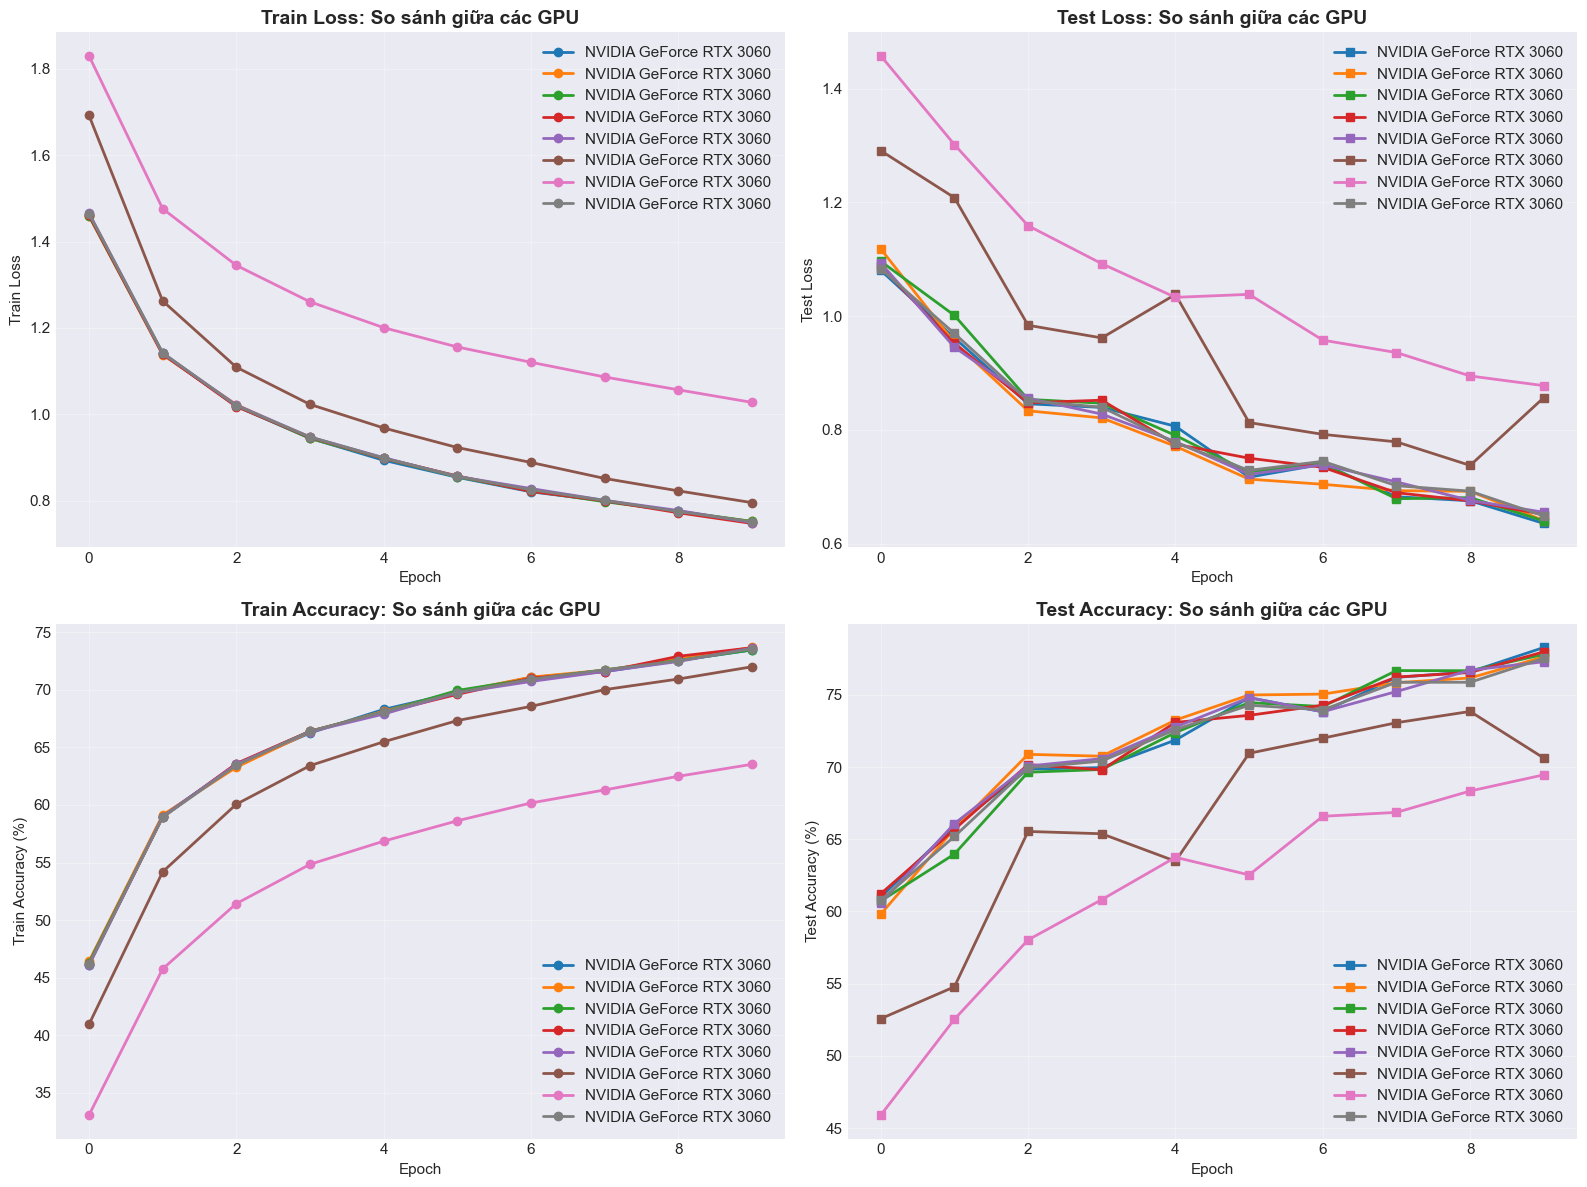


SO SÁNH GIỮA CÁC GPU (Cấu hình: NVIDIA GeForce RTX 3060_tf32_False_amp_False_w0)
GPU                            Final Train Loss   Final Test Loss    Final Test Acc    
----------------------------------------------------------------------------------------------------
NVIDIA GeForce RTX 3060        0.7507             0.6354             78.28             %
NVIDIA GeForce RTX 3060        0.7524             0.6406             77.63             %
NVIDIA GeForce RTX 3060        0.7524             0.6399             77.80             %
NVIDIA GeForce RTX 3060        0.7478             0.6511             77.98             %
NVIDIA GeForce RTX 3060        0.7498             0.6551             77.29             %
NVIDIA GeForce RTX 3060        0.7958             0.8569             70.62             %
NVIDIA GeForce RTX 3060        1.0278             0.8778             69.46             %
NVIDIA GeForce RTX 3060        0.7516             0.6486             77.53             %

Thống kê Test Ac

In [10]:
def compare_same_config_across_gpus(results, config_key):
    """So sánh kết quả cùng cấu hình trên các GPU khác nhau"""
    if config_key not in categories:
        print(f"Không tìm thấy cấu hình: {config_key}")
        return
    
    gpu_results = categories[config_key]
    
    if len(gpu_results) < 2:
        print(f"Chỉ có {len(gpu_results)} kết quả cho cấu hình này. Cần ít nhất 2 GPU để so sánh.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Train Loss
    ax = axes[0, 0]
    for result in gpu_results:
        config = result.get('config', {})
        gpu_name = config.get('gpu_name', result.get('gpu_name', 'Unknown'))
        train_loss = result.get('train_loss', [])
        if train_loss:
            ax.plot(train_loss, label=gpu_name, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss: So sánh giữa các GPU', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Test Loss
    ax = axes[0, 1]
    for result in gpu_results:
        config = result.get('config', {})
        gpu_name = config.get('gpu_name', result.get('gpu_name', 'Unknown'))
        test_loss = result.get('test_loss', [])
        if test_loss:
            ax.plot(test_loss, label=gpu_name, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss: So sánh giữa các GPU', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Train Accuracy
    ax = axes[1, 0]
    for result in gpu_results:
        config = result.get('config', {})
        gpu_name = config.get('gpu_name', result.get('gpu_name', 'Unknown'))
        train_acc = result.get('train_acc', [])
        if train_acc:
            ax.plot(train_acc, label=gpu_name, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Accuracy (%)')
    ax.set_title('Train Accuracy: So sánh giữa các GPU', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Test Accuracy
    ax = axes[1, 1]
    for result in gpu_results:
        config = result.get('config', {})
        gpu_name = config.get('gpu_name', result.get('gpu_name', 'Unknown'))
        test_acc = result.get('test_acc', [])
        if test_acc:
            ax.plot(test_acc, label=gpu_name, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy: So sánh giữa các GPU', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'results/cross_gpu_comparison_{config_key.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Bảng so sánh
    print("\n" + "="*100)
    print(f"SO SÁNH GIỮA CÁC GPU (Cấu hình: {config_key})")
    print("="*100)
    print(f"{'GPU':<30} {'Final Train Loss':<18} {'Final Test Loss':<18} {'Final Test Acc':<18}")
    print("-"*100)
    for result in gpu_results:
        config = result.get('config', {})
        gpu_name = config.get('gpu_name', result.get('gpu_name', 'Unknown'))
        train_loss = result.get('train_loss', [])
        test_loss = result.get('test_loss', [])
        test_acc = result.get('test_acc', [])
        final_train_loss = train_loss[-1] if train_loss else 0
        final_test_loss = test_loss[-1] if test_loss else 0
        final_test_acc = test_acc[-1] if test_acc else 0
        print(f"{gpu_name:<30} {final_train_loss:<18.4f} {final_test_loss:<18.4f} {final_test_acc:<18.2f}%")
    print("="*100)
    
    # Phân tích độ lệch
    if len(gpu_results) >= 2:
        test_accs = [r['test_acc'][-1] for r in gpu_results if r.get('test_acc') and len(r.get('test_acc', [])) > 0]
        if test_accs:
            mean_acc = np.mean(test_accs)
            std_acc = np.std(test_accs)
            max_diff = max(test_accs) - min(test_accs)
            print(f"\nThống kê Test Accuracy:")
            print(f"  Mean: {mean_acc:.2f}%")
            print(f"  Std: {std_acc:.2f}%")
            print(f"  Max difference: {max_diff:.2f}%")
            
            # Đánh giá
            if max_diff < 0.5:
                print(f"  ✓ Statistical reproducibility: TỐT (độ lệch < 0.5%)")
            elif max_diff < 2.0:
                print(f"  ⚠ Statistical reproducibility: CHẤP NHẬN ĐƯỢC (độ lệch < 2%)")
            else:
                print(f"  ✗ Statistical reproducibility: CÓ VẤN ĐỀ (độ lệch >= 2%)")

# Chọn một cấu hình để so sánh (ví dụ: cùng seed, cùng config)
if categories:
    # Lấy cấu hình đầu tiên có nhiều kết quả nhất
    best_config = max(categories.items(), key=lambda x: len(x[1]))
    print(f"\nSo sánh cấu hình: {best_config[0]}")
    compare_same_config_across_gpus(all_results, best_config[0])


## 4. Phân tích Statistical vs Bit-exact Reproducibility


In [11]:
def analyze_reproducibility_type(results):
    """Phân tích xem kết quả có đạt statistical reproducibility hay không"""
    
    # Nhóm theo seed và config (trừ GPU name)
    grouped = defaultdict(list)
    for result in results:
        config = result.get('config', {})
        seed = result.get('seed', 'unknown')
        # Key: seed + config (không tính GPU name)
        key = f"seed_{seed}_tf32_{config.get('tf32_enabled', False)}_amp_{config.get('amp_enabled', False)}_w{config.get('num_workers', 0)}"
        grouped[key].append(result)
    
    print("="*100)
    print("PHÂN TÍCH REPRODUCIBILITY")
    print("="*100)
    
    for key, group_results in grouped.items():
        if len(group_results) < 2:
            continue
        
        print(f"\nNhóm: {key}")
        print(f"Số kết quả: {len(group_results)}")
        
        # Lấy test accuracy cuối cùng
        test_accs = [r['test_acc'][-1] for r in group_results if r.get('test_acc') and len(r.get('test_acc', [])) > 0]
        test_losses = [r['test_loss'][-1] for r in group_results if r.get('test_loss') and len(r.get('test_loss', [])) > 0]
        
        if not test_accs:
            continue
        
        mean_acc = np.mean(test_accs)
        std_acc = np.std(test_accs)
        max_diff_acc = max(test_accs) - min(test_accs)
        
        mean_loss = np.mean(test_losses)
        std_loss = np.std(test_losses)
        max_diff_loss = max(test_losses) - min(test_losses)
        
        print(f"  Test Accuracy:")
        print(f"    Mean: {mean_acc:.4f}%, Std: {std_acc:.4f}%, Max diff: {max_diff_acc:.4f}%")
        print(f"  Test Loss:")
        print(f"    Mean: {mean_loss:.4f}, Std: {std_loss:.4f}, Max diff: {max_diff_loss:.4f}")
        
        # Đánh giá
        print(f"  Đánh giá:")
        if max_diff_acc < 0.5 and max_diff_loss < 0.01:
            print(f"    ✓ Statistical reproducibility: TỐT")
            print(f"      → Các GPU cho kết quả gần giống nhau, có thể chấp nhận")
        elif max_diff_acc < 2.0 and max_diff_loss < 0.05:
            print(f"    ⚠ Statistical reproducibility: CHẤP NHẬN ĐƯỢC")
            print(f"      → Có khác biệt nhỏ nhưng xu hướng giống nhau")
        else:
            print(f"    ✗ Statistical reproducibility: CÓ VẤN ĐỀ")
            print(f"      → Khác biệt lớn, cần kiểm tra cấu hình")
        
        # Kiểm tra xu hướng
        print(f"  Kiểm tra xu hướng:")
        all_trajectories = [r['test_acc'] for r in group_results if r.get('test_acc') and len(r.get('test_acc', [])) > 0]
        if len(all_trajectories) >= 2:
            # Tính correlation giữa các trajectory
            min_len = min(len(t) for t in all_trajectories)
            trajectories_array = np.array([t[:min_len] for t in all_trajectories])
            correlations = []
            for i in range(len(trajectories_array)):
                for j in range(i+1, len(trajectories_array)):
                    corr = np.corrcoef(trajectories_array[i], trajectories_array[j])[0, 1]
                    correlations.append(corr)
            
            mean_corr = np.mean(correlations)
            print(f"    Correlation trung bình giữa các trajectory: {mean_corr:.4f}")
            if mean_corr > 0.99:
                print(f"    ✓ Xu hướng học GIỐNG NHAU (correlation > 0.99)")
            elif mean_corr > 0.95:
                print(f"    ⚠ Xu hướng học TƯƠNG ĐỒNG (correlation > 0.95)")
            else:
                print(f"    ✗ Xu hướng học KHÁC NHAU (correlation < 0.95)")

analyze_reproducibility_type(all_results)


PHÂN TÍCH REPRODUCIBILITY

Nhóm: seed_42_tf32_False_amp_False_w0
Số kết quả: 39
  Test Accuracy:
    Mean: 75.5454%, Std: 3.3807%, Max diff: 9.7600%
  Test Loss:
    Mean: 0.7007, Std: 0.0922, Max diff: 0.2748
  Đánh giá:
    ✗ Statistical reproducibility: CÓ VẤN ĐỀ
      → Khác biệt lớn, cần kiểm tra cấu hình
  Kiểm tra xu hướng:
    Correlation trung bình giữa các trajectory: 0.9559
    ⚠ Xu hướng học TƯƠNG ĐỒNG (correlation > 0.95)

Nhóm: seed_42_tf32_False_amp_False_w4
Số kết quả: 13
  Test Accuracy:
    Mean: 76.2885%, Std: 0.4220%, Max diff: 1.3900%
  Test Loss:
    Mean: 0.6737, Std: 0.0118, Max diff: 0.0399
  Đánh giá:
    ⚠ Statistical reproducibility: CHẤP NHẬN ĐƯỢC
      → Có khác biệt nhỏ nhưng xu hướng giống nhau
  Kiểm tra xu hướng:
    Correlation trung bình giữa các trajectory: 0.9907
    ✓ Xu hướng học GIỐNG NHAU (correlation > 0.99)

Nhóm: seed_42_tf32_False_amp_True_w0
Số kết quả: 4
  Test Accuracy:
    Mean: 77.6000%, Std: 0.3506%, Max diff: 0.9000%
  Test Loss:
   

In [12]:
def create_summary_table(results):
    """Tạo bảng tổng hợp tất cả kết quả"""
    rows = []
    
    for result in results:
        config = result.get('config', {})
        train_loss = result.get('train_loss', [])
        test_loss = result.get('test_loss', [])
        train_acc = result.get('train_acc', [])
        test_acc = result.get('test_acc', [])
        row = {
            'GPU': config.get('gpu_name', result.get('gpu_name', 'Unknown')),
            'TF32': config.get('tf32_enabled', result.get('tf32_enabled', False)),
            'AMP': config.get('amp_enabled', result.get('amp_enabled', False)),
            'Workers': config.get('num_workers', result.get('num_workers', 0)),
            'Seed': result.get('seed', 'N/A'),
            'Epochs': len(train_loss),
            'Final Train Loss': train_loss[-1] if train_loss else None,
            'Final Test Loss': test_loss[-1] if test_loss else None,
            'Final Train Acc': train_acc[-1] if train_acc else None,
            'Final Test Acc': test_acc[-1] if test_acc else None,
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

# Tạo và hiển thị bảng
summary_df = create_summary_table(all_results)
print("="*120)
print("BẢNG TỔNG HỢP TẤT CẢ KẾT QUẢ")
print("="*120)
print(summary_df.to_string(index=False))
print("="*120)

# Lưu ra CSV
summary_df.to_csv('results/summary_all_results.csv', index=False)
print("\nĐã lưu bảng tổng hợp vào: results/summary_all_results.csv")


BẢNG TỔNG HỢP TẤT CẢ KẾT QUẢ
                    GPU  TF32   AMP  Workers  Seed  Epochs  Final Train Loss  Final Test Loss  Final Train Acc  Final Test Acc
  NVIDIA A100-SXM4-40GB False False        0    42      10          0.752930         0.632883           73.492           77.81
  NVIDIA A100-SXM4-40GB False False        0    42      10          0.748084         0.640494           73.518           77.61
  NVIDIA A100-SXM4-40GB False False        4    42      10          0.754082         0.694373           73.426           75.85
  NVIDIA A100-SXM4-40GB False False        4    42      10          0.746560         0.670817           73.354           76.22
  NVIDIA A100-SXM4-40GB False  True        0    42      10          0.743465         0.663038           73.606           77.21
  NVIDIA A100-SXM4-40GB  True False        4    42      10          0.741469         0.645812           73.880           77.07
NVIDIA GeForce RTX 3060 False False        0    42      10          0.750745      

## 6. Kết luận và Khuyến nghị

**Phân biệt Statistical vs Bit-exact Reproducibility**:

1. **Bit-exact Reproducibility**: 
   - Kết quả hoàn toàn giống nhau (bit-by-bit)
   - Rất khó đạt được trên GPU khác nhau
   - Không cần thiết trong hầu hết trường hợp

2. **Statistical Reproducibility**:
   - Kết quả có cùng xu hướng và ở cùng cấp độ
   - Loss có cùng xu hướng giảm
   - Validation performance ở cùng cấp độ
   - **Đây là mục tiêu thực tế** khi làm việc với GPU khác nhau

**Khi nào sai lệch là chấp nhận được**:
- ✅ Test accuracy lệch < 0.5%: TỐT
- ⚠️ Test accuracy lệch 0.5-2%: CHẤP NHẬN ĐƯỢC (nếu xu hướng giống nhau)
- ❌ Test accuracy lệch > 2%: CẦN KIỂM TRA

**Khi nào sai lệch là vấn đề nghiêm trọng**:
- Loss lệch lớn ngay từ epoch đầu
- Quỹ đạo học khác hẳn (một cái overfit, một cái underfit)
- Early stopping hoặc checkpoint được chọn khác nhau
- Correlation giữa các trajectory < 0.95

**Khuyến nghị**:
- So sánh **xu hướng** (trend), không phải giá trị tuyệt đối
- Ghi rõ GPU + precision trong báo cáo thực nghiệm
- Không debug mô hình chỉ dựa trên accuracy tuyệt đối
